In [98]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from haversine import haversine, Unit
from sklearn.impute import KNNImputer

import warnings

In [99]:
warnings.filterwarnings("ignore")

In [100]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [101]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [102]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [104]:
# Limpiar longitud  y latitud

print(sum(df['pickup_longitude'] > 180)) # valores de longitud y latitud por fuera de (-180 - 180) y (-90 - 90), respectivamente
print(sum(df['dropoff_latitude'] < -90))
print(sum(df['dropoff_longitude'] < -180))
print(sum(df['pickup_latitude'] > 90))
print(sum(df['pickup_latitude'] == 0))
print(sum(df['pickup_longitude'] == 0))
print(sum(df['dropoff_latitude'] == 0))
print(sum(df['dropoff_longitude'] == 0))
print(sum((df['pickup_longitude'] == 0)& (df['dropoff_latitude'] == 0)& (df['dropoff_longitude'] == 0) & (df['pickup_latitude'] == 0)))
print(sum(df['fare_amount']==0))

0
1
2
4
3782
3786
3758
3764
3587
5


In [105]:
# REEMPLAZO DE 0 DE LAS COLUMNAS DE COORDENADAS POR NAN, PARA EL ESCALADO

float_cols = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude']
for col in float_cols:
    df.loc[df[col] == 0, col] = np.nan

In [106]:
# borrado de los valores por fuera de estos valores, representan un % insignificante, MANTENIENDO LOS NAN

df = df[df['dropoff_latitude'].between(-90, 90) | df['dropoff_latitude'].isna()] 
df = df[df['pickup_longitude'].between(-180, 180) | df['pickup_longitude'].isna()]
df = df[df['pickup_latitude'].between(-90, 90)| df['pickup_latitude'].isna()]
df = df[df['dropoff_longitude'].between(-180, 180) | df['dropoff_longitude'].isna()]

In [107]:
print(sum(df['dropoff_longitude'] == df["pickup_longitude"]))
print(sum(df['dropoff_latitude'] == df["pickup_latitude"]))
# TENEMOS QUE VER QUÉ HACEMOS CON LOS QUE TIENEN PUNTO DE SALIDA Y RETORNO IGUALES

2081


2090


In [108]:
# % de nan en cada columna
(df.isna().sum() / len(df)) * 100

key                  0.000000
date                 0.000000
fare_amount          0.000000
pickup_datetime      0.000000
pickup_longitude     1.893114
pickup_latitude      1.891113
dropoff_longitude    1.882613
dropoff_latitude     1.879613
passenger_count      0.000000
dtype: float64

In [109]:
df_limpio = df

In [110]:
df_limpio.info()
df_limpio.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 199988 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199988 non-null  int64  
 1   date               199988 non-null  object 
 2   fare_amount        199988 non-null  float64
 3   pickup_datetime    199988 non-null  object 
 4   pickup_longitude   196202 non-null  float64
 5   pickup_latitude    196206 non-null  float64
 6   dropoff_longitude  196223 non-null  float64
 7   dropoff_latitude   196229 non-null  float64
 8   passenger_count    199988 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 15.3+ MB


key                     0
date                    0
fare_amount             0
pickup_datetime         0
pickup_longitude     3786
pickup_latitude      3782
dropoff_longitude    3765
dropoff_latitude     3759
passenger_count         0
dtype: int64

In [111]:
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


# Dividir datos de entrenamiento y testeo

In [112]:
x = df_limpio.drop('fare_amount', axis=1)
y = df_limpio['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Analisis exploratorio de datos

In [113]:
X_train.describe()

,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.599900e+05,156917.000000,156921.000000,156926.000000,156932.000000,159990.000000
mean,2.772714e+07,-73.900756,40.687302,-73.902351,40.687059,1.679505
std,1.602099e+07,2.812751,2.640015,2.774024,2.642838,1.303397
min,1.000000e+00,-93.824668,-74.015515,-75.458979,-74.015750,0.000000
25%,1.383602e+07,-73.992281,40.736365,-73.991596,40.735192,1.000000
50%,2.776453e+07,-73.982102,40.753272,-73.980532,40.753728,1.000000
75%,4.158793e+07,-73.968295,40.767560,-73.965273,40.768331,2.000000
max,5.542357e+07,40.808425,47.383332,40.831932,45.031598,6.000000


## Valores faltantes

In [114]:
X_train.shape

(159990, 8)

In [115]:
X_train.isnull().sum()

key                     0
date                    0
pickup_datetime         0
pickup_longitude     3073
pickup_latitude      3069
dropoff_longitude    3064
dropoff_latitude     3058
passenger_count         0
dtype: int64

In [116]:
# ESCALADO ROBUSTO

scaler = RobustScaler()
cols_a_escalar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

# Identifica las filas sin NaN
filas_sin_nan = ~X_train[cols_a_escalar].isna().any(axis=1)
df_sin_nan = X_train.loc[filas_sin_nan, cols_a_escalar]

#  Escala sólo las filas sin NaN
df_sin_nan_escalado_array = scaler.fit_transform(df_sin_nan)

#  Crea un nuevo DataFrame con los datos escalados, manteniendo el índice original
columnas_escaladas = [col + '_escalada' for col in cols_a_escalar]
df_sin_nan_escalado = pd.DataFrame(df_sin_nan_escalado_array, columns=columnas_escaladas, index=df_sin_nan.index)

# Une las nuevas columnas escaladas al DataFrame X_train original
X_train[columnas_escaladas] = np.nan

#  Rellena las nuevas columnas con los valores escalados
X_train.loc[df_sin_nan_escalado.index, columnas_escaladas] = df_sin_nan_escalado.values

In [117]:
# IMPUTACIÓN CON KNN A LAS COORDENDAS

imputer = KNNImputer(n_neighbors=5)

cols = ['pickup_longitude_escalada','pickup_latitude_escalada','dropoff_latitude_escalada','dropoff_longitude_escalada']

X_train[cols] = imputer.fit_transform(X_train[cols])

In [118]:
print(X_train[cols].dtypes)
print(X_train[cols].isna().sum())

pickup_longitude_escalada     float64
pickup_latitude_escalada      float64
dropoff_latitude_escalada     float64
dropoff_longitude_escalada    float64
dtype: object
pickup_longitude_escalada     0
pickup_latitude_escalada      0
dropoff_latitude_escalada     0
dropoff_longitude_escalada    0
dtype: int64


In [119]:
col_escaladas = ['pickup_longitude_escalada', 'pickup_latitude_escalada', 'dropoff_latitude_escalada', 'dropoff_longitude_escalada', 'passenger_count_escalada']

# Desescala los datos de TODAS las columnas
datos_desescalados_array = scaler.inverse_transform(X_train[col_escaladas].values)

# Crea una lista con los nombres de las nuevas columnas con el sufijo '_desescalada'
col_desescaladas = [col.replace('_escalada', '_desescalada') for col in col_escaladas]

# 3. Asigna los valores desescalados a las NUEVAS columnas en X_train
X_train[col_desescaladas] = datos_desescalados_array

In [120]:
print(sum(X_train['pickup_longitude'] > 180)) # valores de longitud y latitud por fuera de (-180 - 180) y (-90 - 90), respectivamente
print(sum(X_train['dropoff_latitude'] < -90))
print(sum(X_train['dropoff_longitude'] < -180))
print(sum(X_train['pickup_latitude'] > 90))
(sum(X_train['dropoff_latitude'] < -90)) / len(X_train) *100

0
0
0
0


0.0

In [121]:
# Crea la máscara booleana para los datos válidos
valid_dropoff_latitude_mask = X_train['dropoff_latitude_desescalada'].between(-90, 90)

# Aplica el filtro a X_train
X_train = X_train[valid_dropoff_latitude_mask]

# Y APLICA EL MISMO FILTRO A Y_TRAIN USANDO LA MISMA MÁSCARA
y_train = y_train[valid_dropoff_latitude_mask]

print("\nDespués de filtrar:")
print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de y_train: {y_train.shape}")


Después de filtrar:
Tamaño de X_train: (159891, 18)
Tamaño de y_train: (159891,)


In [122]:
# Cálculo de distancia recorrida en km según latitud y longitud(inicio y destino)
X_train['distancia_km'] = X_train.apply(lambda row: haversine((row['pickup_latitude'], row['pickup_longitude']),(row['dropoff_latitude'], row['dropoff_longitude'])), axis=1)
X_train['distancia_km'].describe()

count    156664.000000
mean          4.238833
std          70.746746
min           0.000000
25%           1.254106
50%           2.155490
75%           3.905491
max        8585.341104
Name: distancia_km, dtype: float64

## Tratamiento fechas

In [123]:
X_train['day_week_num'] = pd.to_datetime(X_train['date'], utc=True) # convierte a datetime
X_train['day_week_num'] = X_train['day_week_num'].dt.dayofweek # funcón para sacar el día de la semana (numérico)
X_train['day_week_num']

48971     1
131208    5
15045     4
11426     3
49247     0
         ..
119887    3
103701    4
131940    6
146877    5
121966    3
Name: day_week_num, Length: 159891, dtype: int32

In [124]:
# Función Circular encoding

def circular_encoding(X_train, column, n_categorias):
    sin_col = f"{column}_sin"
    cos_col = f"{column}_cos"
    X_train[sin_col] = np.sin((2 * np.pi * (X_train[column]))/ n_categorias)
    X_train[cos_col] = np.cos((2 * np.pi * (X_train[column])) / n_categorias)
    return X_train

X_train = circular_encoding(X_train, 'day_week_num', 7)

X_train['day_week_num_sin']

48971     0.781831
131208   -0.974928
15045    -0.433884
11426     0.433884
49247     0.000000
            ...   
119887    0.433884
103701   -0.433884
131940   -0.781831
146877   -0.974928
121966    0.433884
Name: day_week_num_sin, Length: 159891, dtype: float64

In [125]:
X_train['fecha_hora'] = pd.to_datetime(X_train['date'].str.replace(' UTC', ''), utc=True) #convertirmos a datetime

X_train['hora'] = X_train['fecha_hora'].dt.hour # extraemos la hora de la fecha general

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']#O LO HACEMOS NUMERICO PARA DESPUÉS PODER HACER CALCULOS DE COSTO + DÍA DE LA SEMANA EN LA FUNCIÓN DE REGRESIÓN?

bins = [0, 6, 12, 18, 24] # bins

X_train['period_of_the_day'] = pd.cut(X_train['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True) # genera una columna nueva con las variables categóricas

X_train['period_of_the_day']

48971         Tarde
131208        Tarde
15045         Tarde
11426         Noche
49247         Noche
            ...    
119887       Mañana
103701       Mañana
131940        Tarde
146877    Madrugada
121966        Noche
Name: period_of_the_day, Length: 159891, dtype: category
Categories (4, object): ['Madrugada' < 'Mañana' < 'Tarde' < 'Noche']

In [126]:
# Circular enconding para el momento del día

X_train['fecha_hora'] = pd.to_datetime(X_train['date'].str.replace(' UTC', ''), utc=True) #convertirmos a datetime

X_train['hora'] = X_train['fecha_hora'].dt.hour # extraemos la hora de la fecha general

X_train = circular_encoding(X_train, 'hora', 24)

X_train['hora_cos']

48971    -0.500000
131208   -0.707107
15045    -0.707107
11426     0.965926
49247     0.500000
            ...   
119887   -0.500000
103701   -0.866025
131940   -0.866025
146877    0.707107
121966    0.707107
Name: hora_cos, Length: 159891, dtype: float64

In [127]:
# Cantidad de pasajeros mayores a 10
print(f"\nCantidad de pasajeros mayores a 10 ANTES del filtro: {(X_train['passenger_count_desescalada'] > 10).sum()}")

# Crea la máscara para pasajeros <= 10
valid_passengers_mask = X_train['passenger_count_desescalada'] <= 10

# Aplica el filtro a X_train
X_train = X_train[valid_passengers_mask]

# Y APLICA EL MISMO FILTRO A Y_TRAIN USANDO LA MISMA MÁSCARA
y_train = y_train[valid_passengers_mask]

# Gastos menores a 0 dolares y_train
print(f"\nCantidad de gastos menores a 0 ANTES del filtro: {(y_train < 0).sum()}")

# Crea la máscara para gastos mayores o iguales a 0
valid_fare_amount_mask = y_train >= 0

# Aplica el filtro a y_train
y_train = y_train[valid_fare_amount_mask]

# Y APLICA EL MISMO FILTRO A X_TRAIN USANDO LA MISMA MÁSCARA
X_train = X_train[valid_fare_amount_mask]

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de y_train: {y_train.shape}")


Cantidad de pasajeros mayores a 10 ANTES del filtro: 0

Cantidad de gastos menores a 0 ANTES del filtro: 12
Tamaño de X_train: (156652, 27)
Tamaño de y_train: (156652,)


## Distribuciones

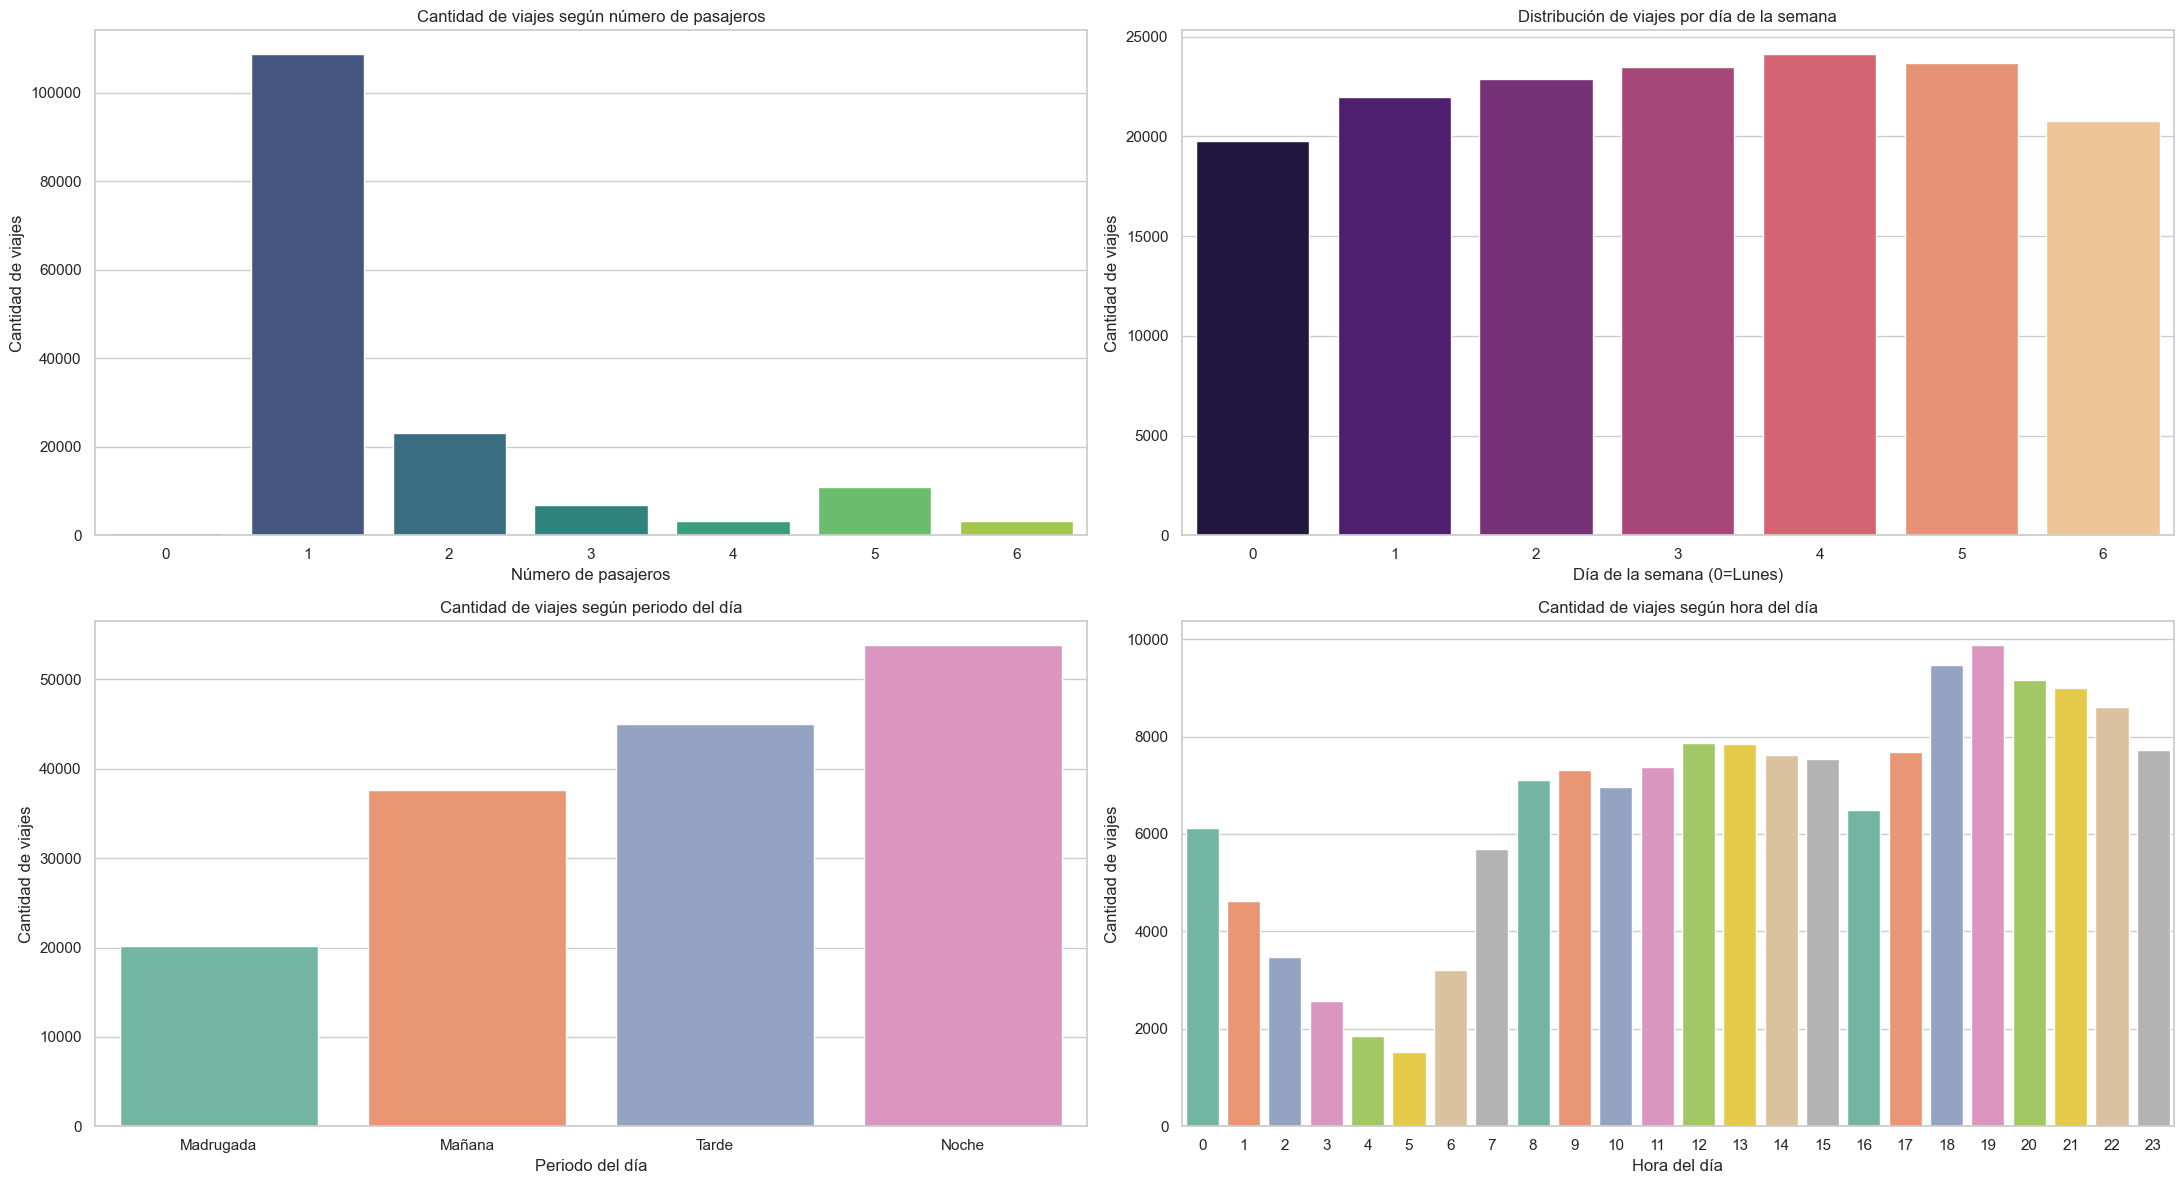

In [128]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

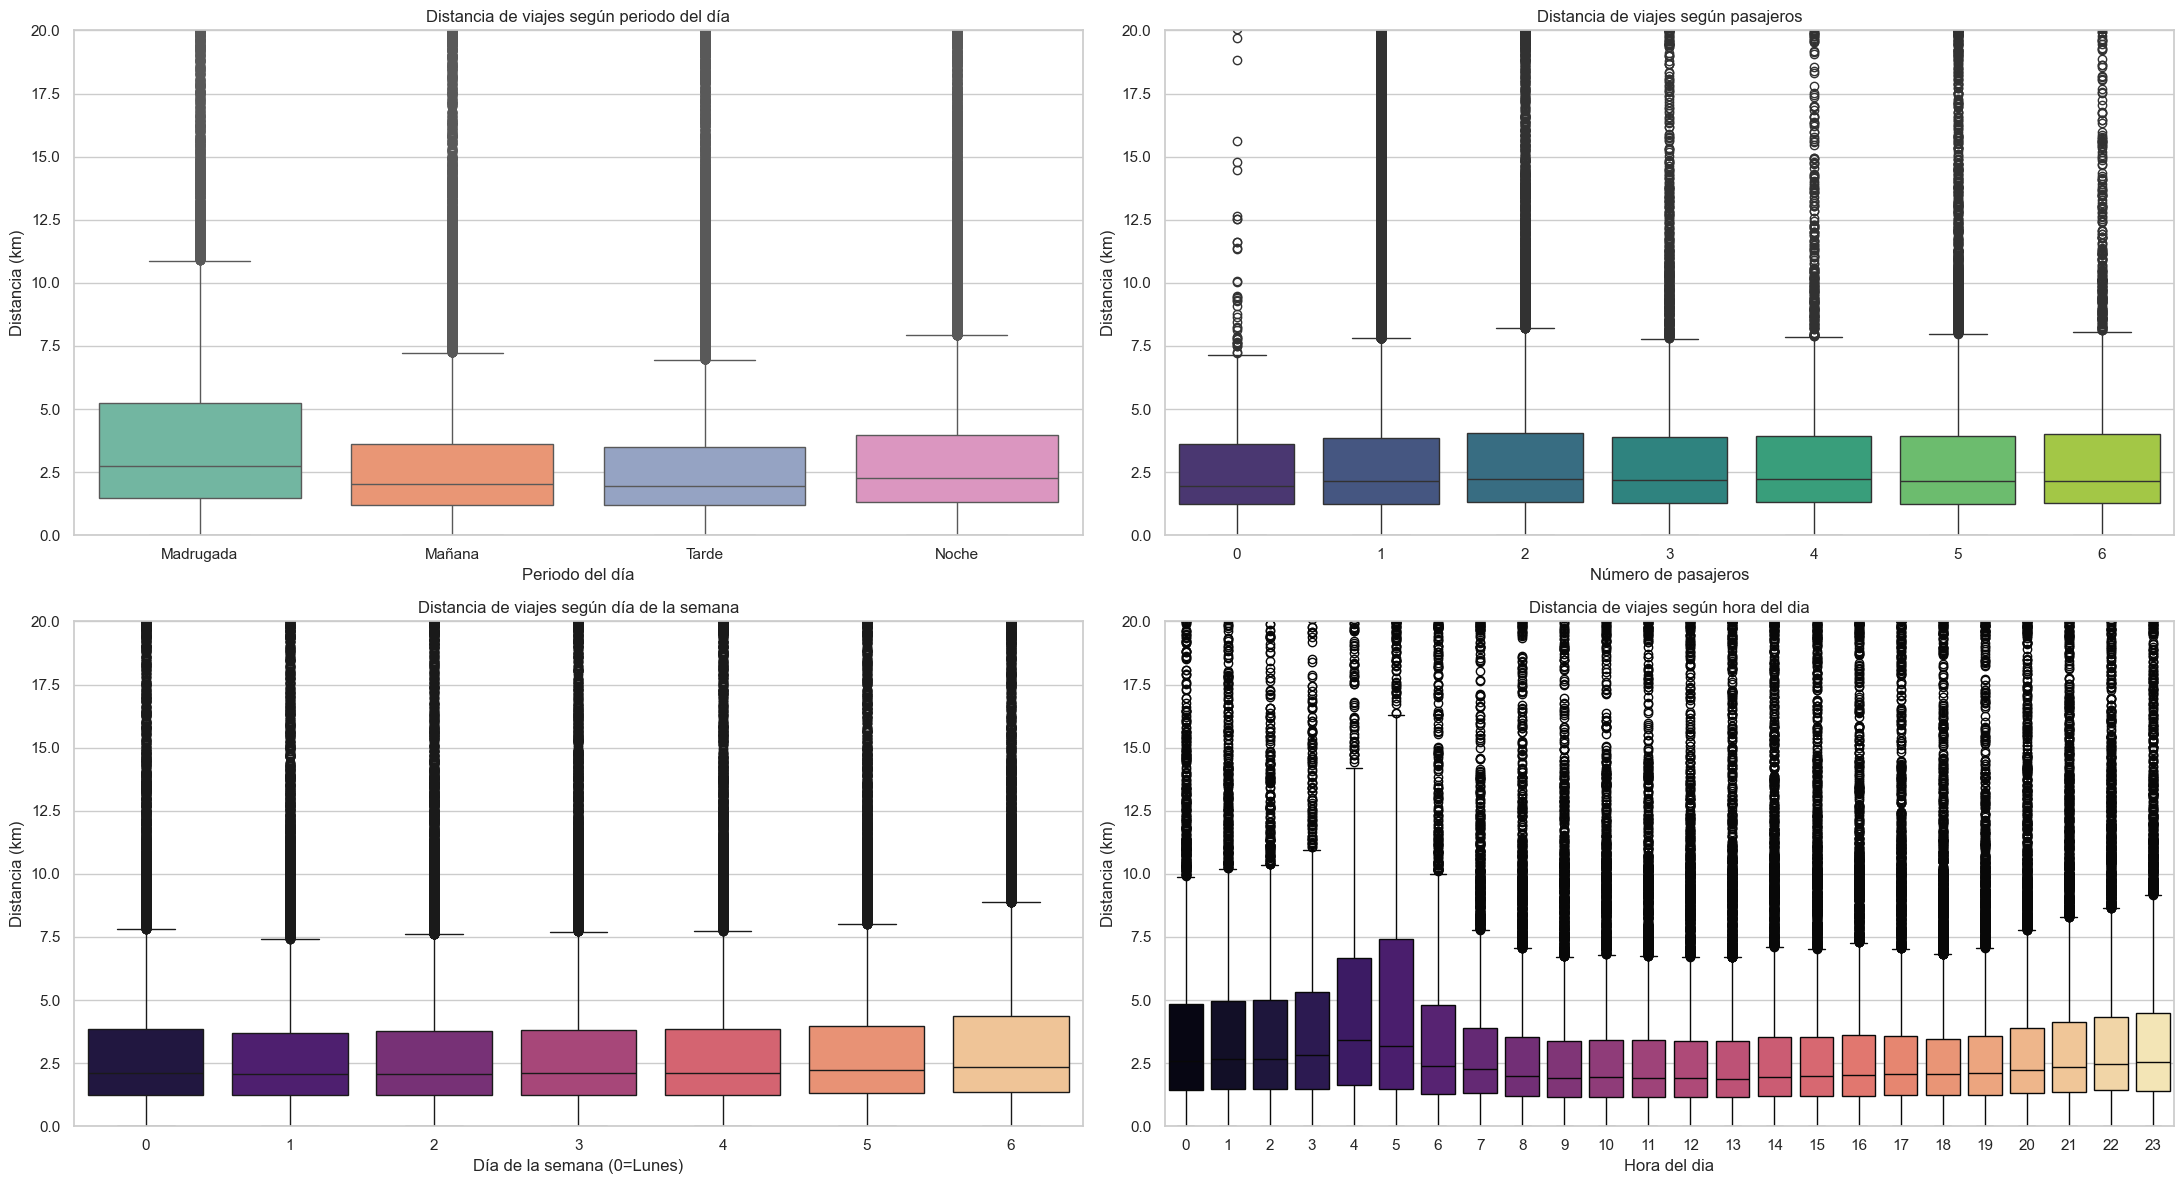

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Distancia según periodo del día
sns.boxplot(
    data=X_train,
    x="period_of_the_day",
    y="distancia_km",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[0,0],
    palette="Set2"
)
axes[0,0].set_ylim(0, 20)
axes[0,0].set_title("Distancia de viajes según periodo del día")
axes[0,0].set_xlabel("Periodo del día")
axes[0,0].set_ylabel("Distancia (km)")

# Distancia vs número de pasajeros
sns.boxplot(
    data=X_train,
    x="passenger_count",
    y="distancia_km",
    ax=axes[0,1],
    palette="viridis"
)
axes[0,1].set_ylim(0, 20)
axes[0,1].set_title("Distancia de viajes según pasajeros")
axes[0,1].set_xlabel("Número de pasajeros")
axes[0,1].set_ylabel("Distancia (km)")

# Distancia por día de la semana
sns.boxplot(
    data=X_train,
    x="day_week_num",
    y="distancia_km",
    ax=axes[1,0],
    palette="magma"
)
axes[1,0].set_ylim(0, 20)
axes[1,0].set_title("Distancia de viajes según día de la semana")
axes[1,0].set_xlabel("Día de la semana (0=Lunes)")
axes[1,0].set_ylabel("Distancia (km)")

# Distancia por día de la semana
sns.boxplot(
    data=X_train,
    x="hora",
    y="distancia_km",
    ax=axes[1,1],
    palette="magma"
)
axes[1,1].set_ylim(0, 20)
axes[1,1].set_title("Distancia de viajes según hora del dia")
axes[1,1].set_xlabel("Hora del dia")
axes[1,1].set_ylabel("Distancia (km)")


plt.tight_layout()
plt.show()

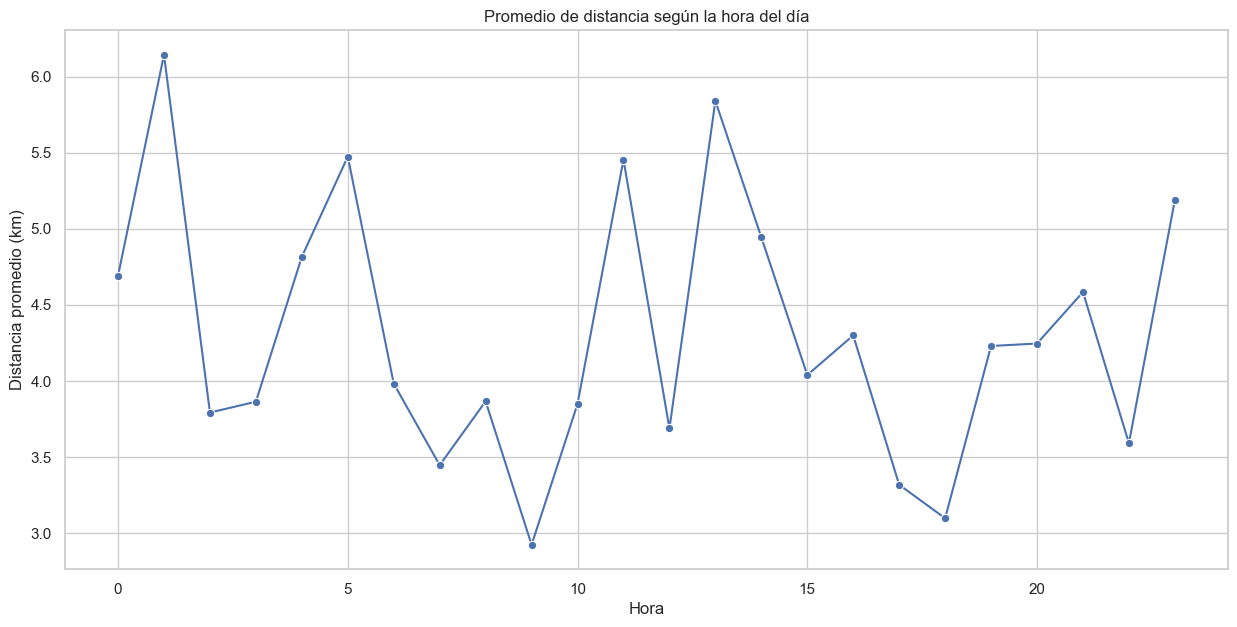

In [130]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distancia_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()


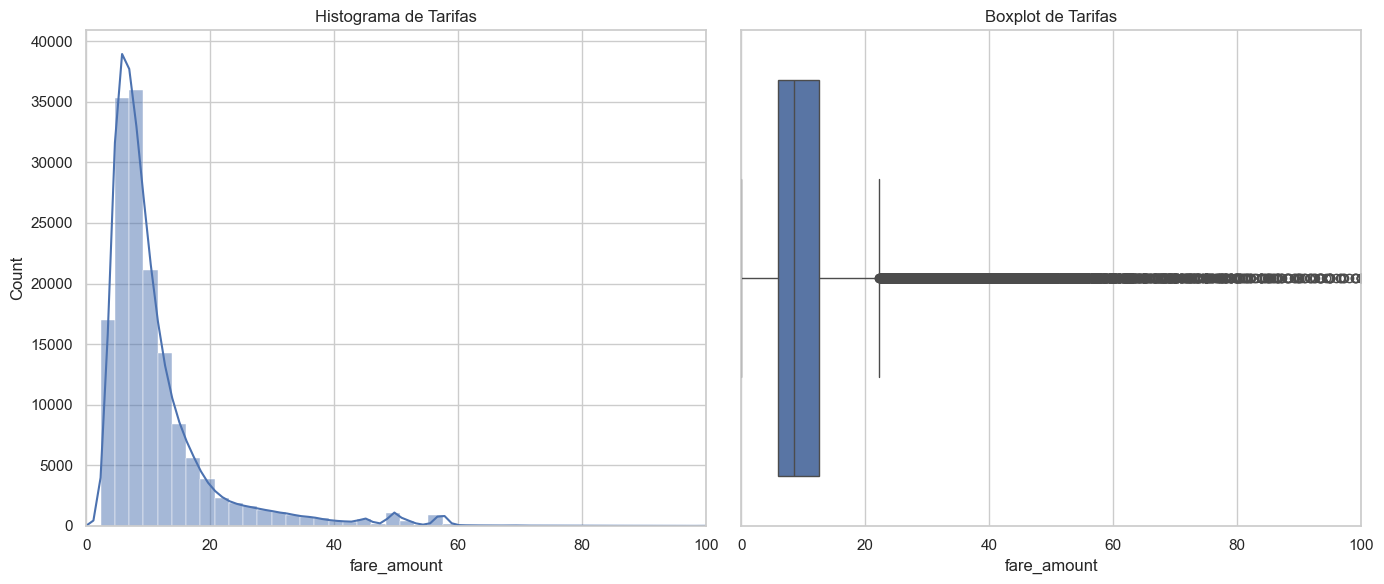

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 100)  # límite para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

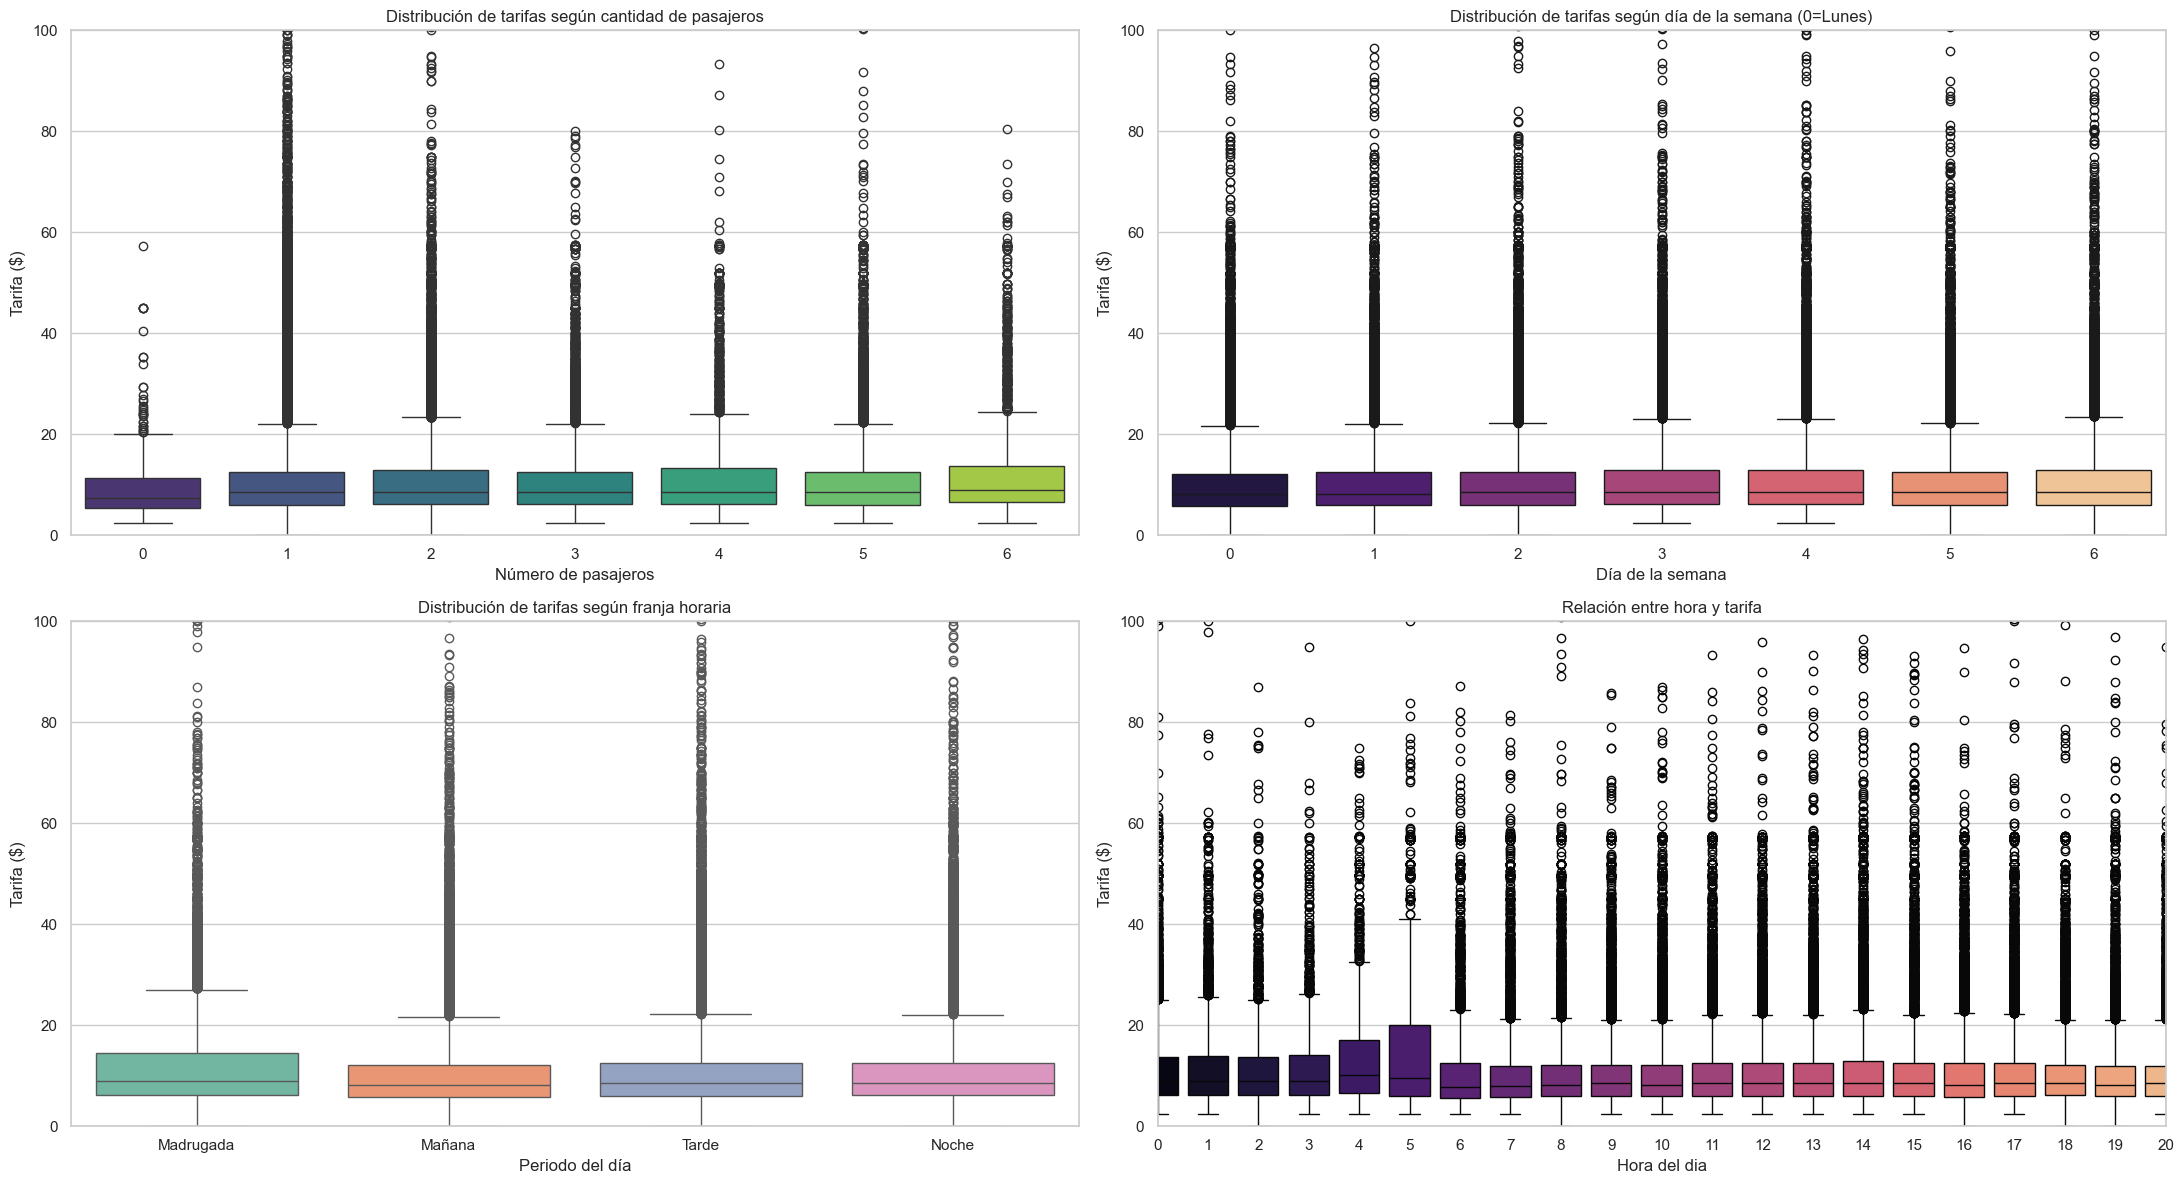

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Distribución de tarifas según pasajeros
sns.boxplot(x=X_train["passenger_count"], y=y_train, ax=axes[0,0], palette="viridis")
axes[0,0].set_ylim(0, 100)
axes[0,0].set_title("Distribución de tarifas según cantidad de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Tarifa ($)")

# Distribución de tarifas por día de la semana
sns.boxplot(x=X_train["day_week_num"], y=y_train, ax=axes[0,1], palette="magma")
axes[0,1].set_ylim(0, 100)
axes[0,1].set_title("Distribución de tarifas según día de la semana (0=Lunes)")
axes[0,1].set_xlabel("Día de la semana")
axes[0,1].set_ylabel("Tarifa ($)")

# Distribución de tarifas por franja horaria del día
sns.boxplot(x=X_train["period_of_the_day"], y=y_train, 
            order=["Madrugada","Mañana","Tarde","Noche"],
            ax=axes[1,0], palette="Set2")
axes[1,0].set_ylim(0, 100)
axes[1,0].set_title("Distribución de tarifas según franja horaria")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Tarifa ($)")

# Relación entre distancia y tarifa (dispersión)
sns.boxplot(x=X_train["hora"], y=y_train, ax=axes[1,1],palette="magma")
axes[1,1].set_xlim(0, 20)   # limitar a 20 km para evitar outliers extremos
axes[1,1].set_ylim(0, 100)
axes[1,1].set_title("Relación entre hora y tarifa")
axes[1,1].set_xlabel("Hora del dia")
axes[1,1].set_ylabel("Tarifa ($)")


plt.tight_layout()
plt.show()

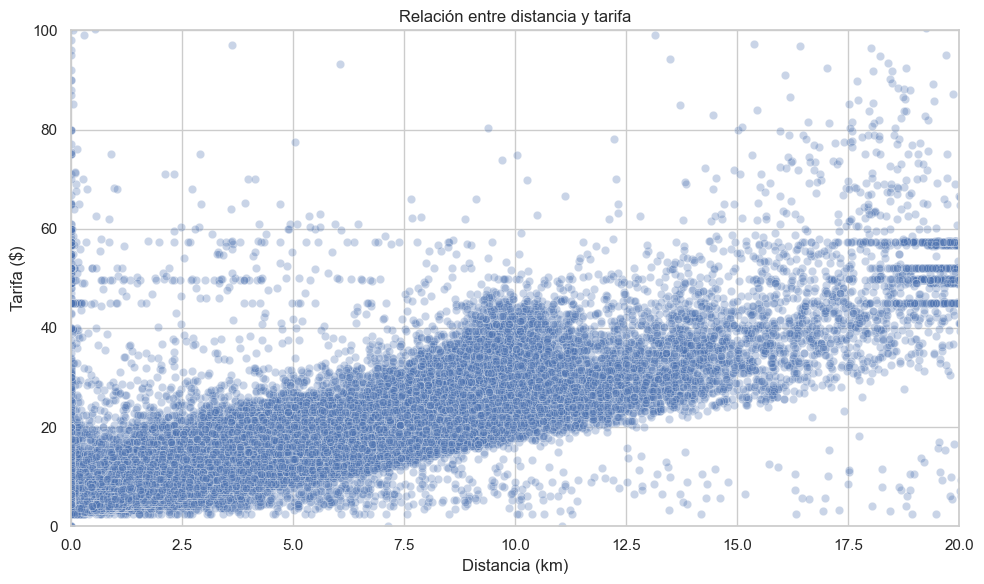

In [133]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

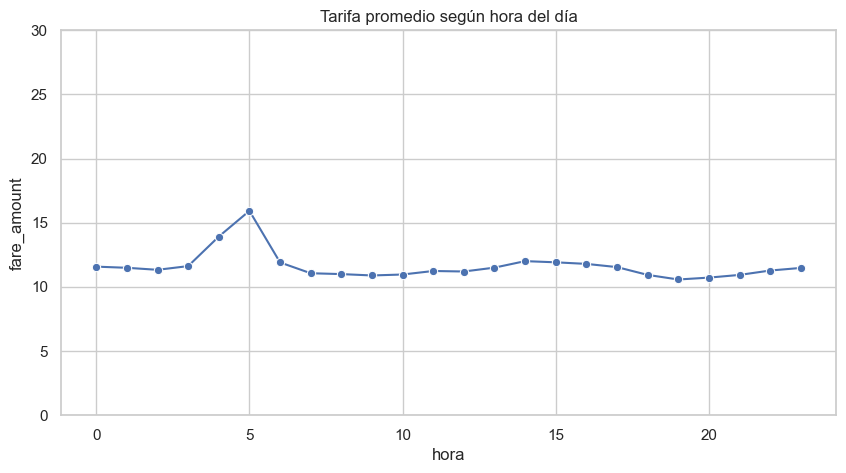

In [134]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

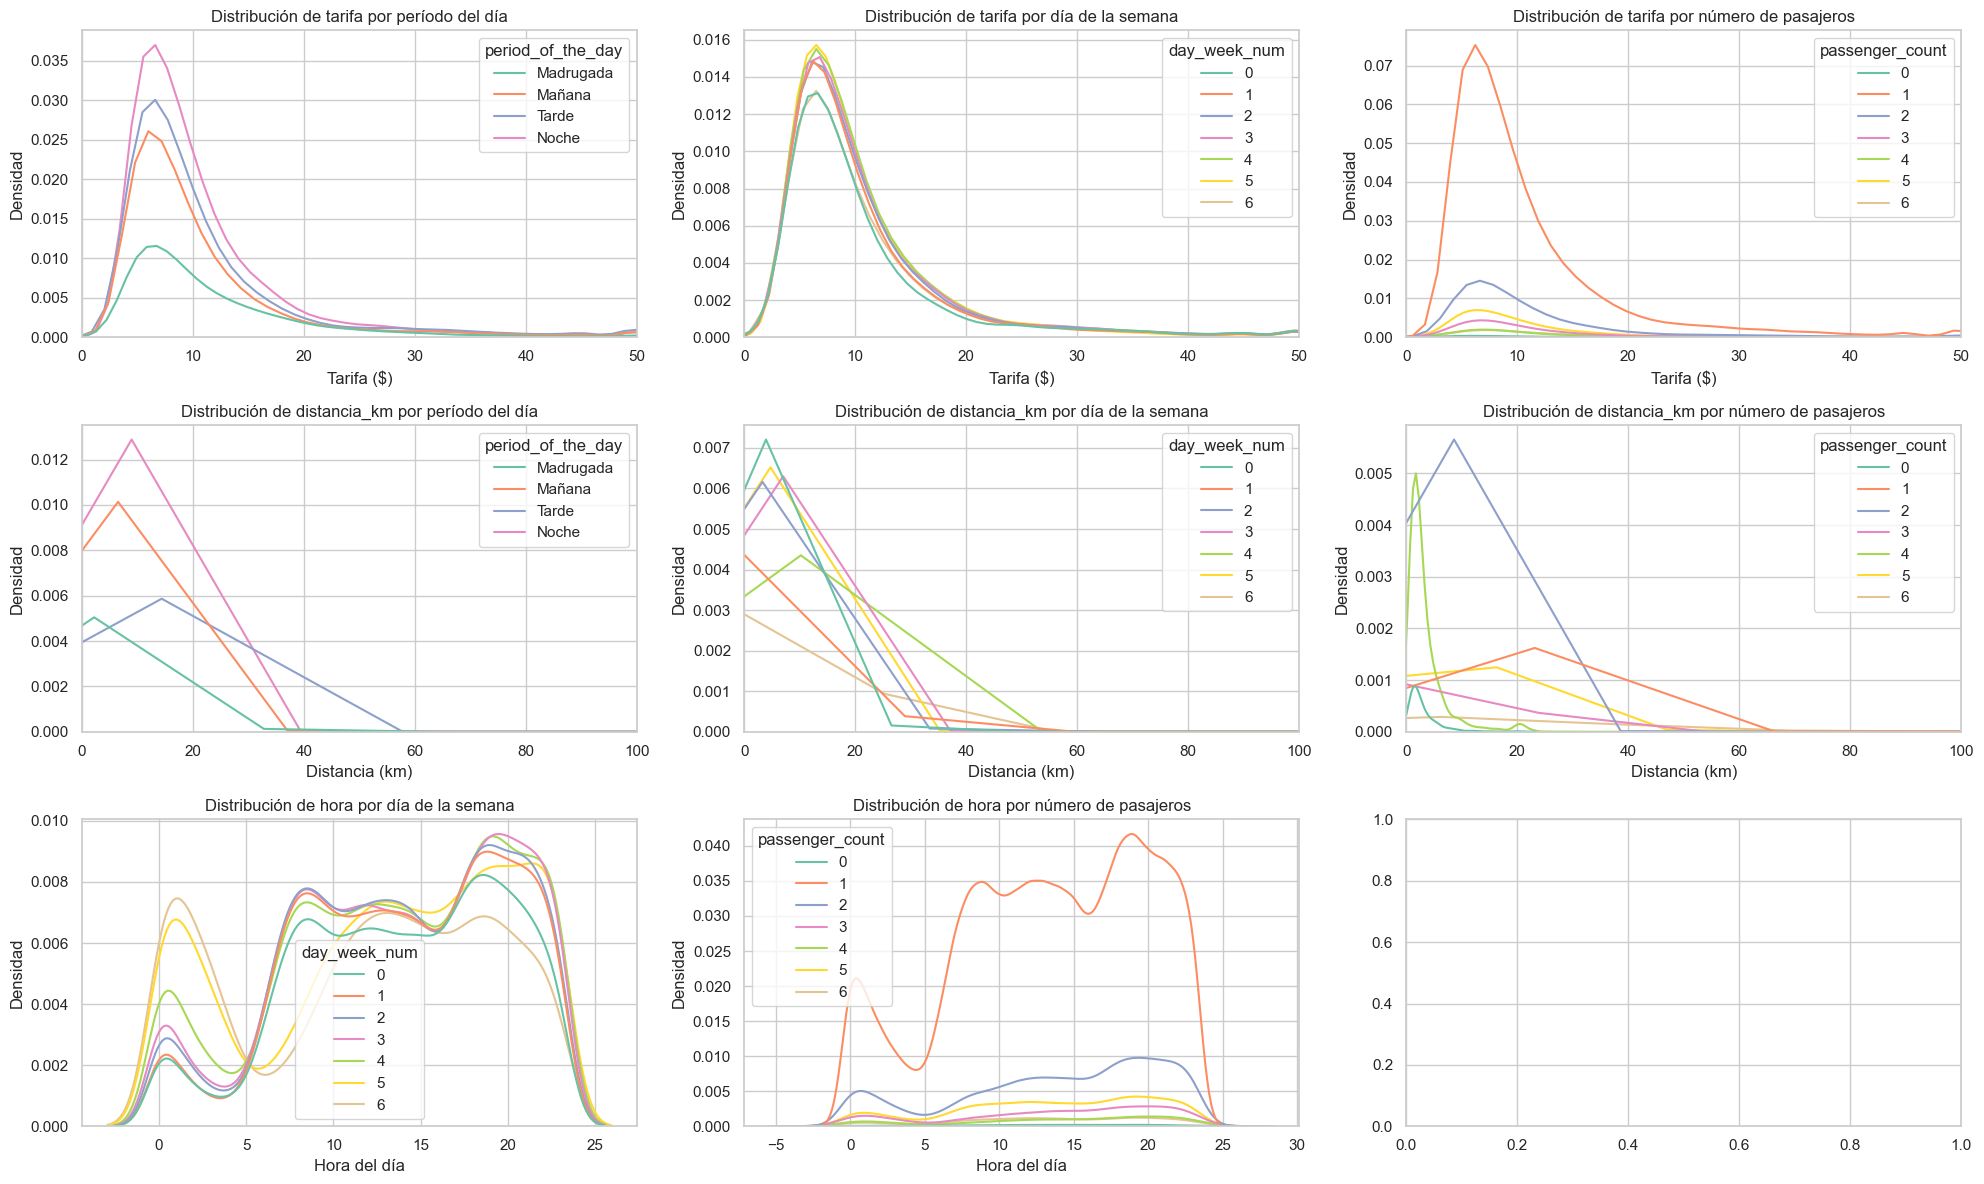

In [135]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distancia_km por período del día
sns.kdeplot(data=X_train, x='distancia_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 100)
ax4.set_title("Distribución de distancia_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distancia_km por día de la semana
sns.kdeplot(data=X_train, x='distancia_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 100)
ax5.set_title("Distribución de distancia_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distancia_km por número de pasajeros
sns.kdeplot(data=X_train, x='distancia_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 100)
ax6.set_title("Distribución de distancia_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

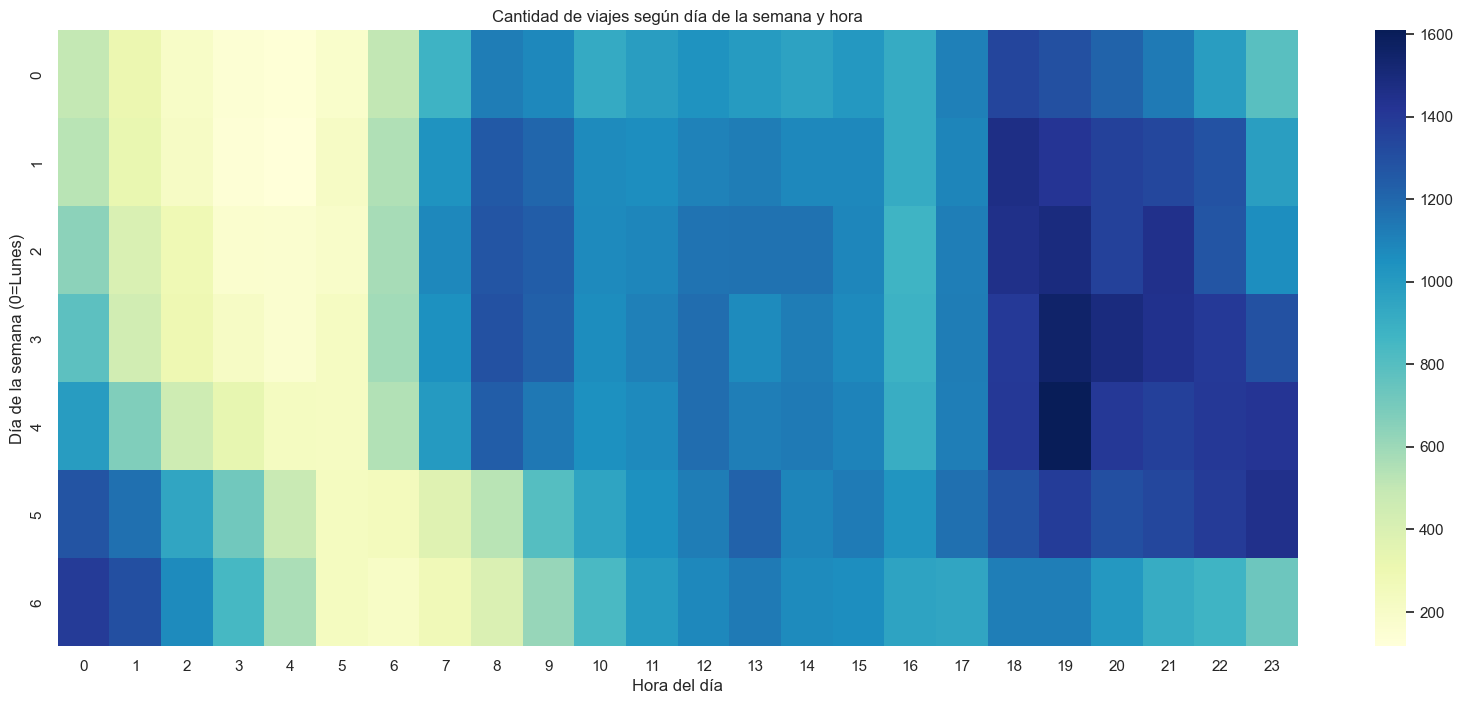

In [136]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

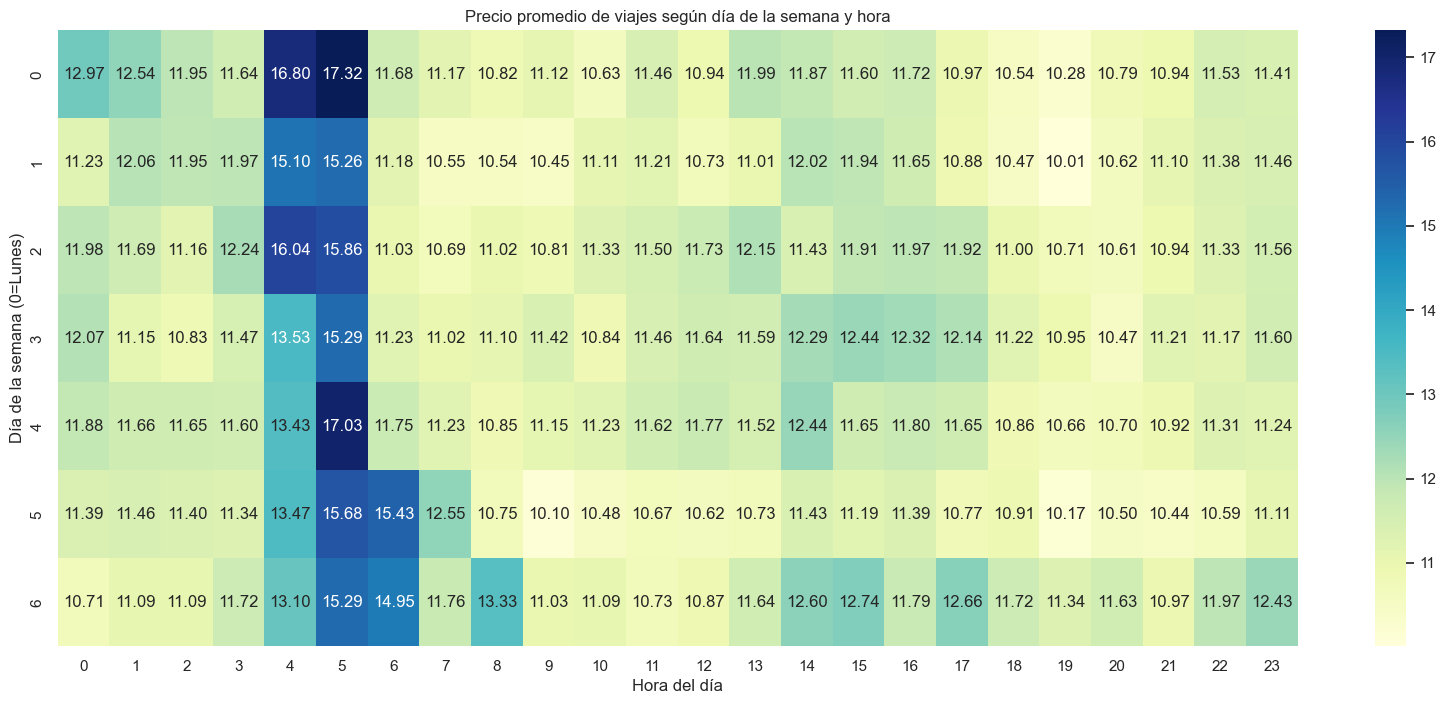

In [137]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

## Correlaciones

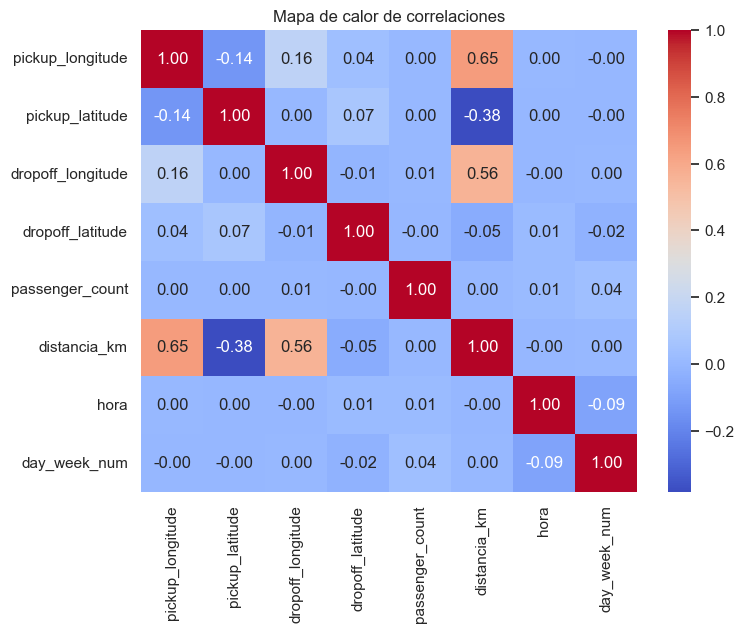

In [138]:
# Heatmap de correlaciones numéricas

plt.figure(figsize=(8,6))
corr = X_train[['pickup_longitude','pickup_latitude',
                'dropoff_longitude','dropoff_latitude',
                'passenger_count','distancia_km','hora','day_week_num']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

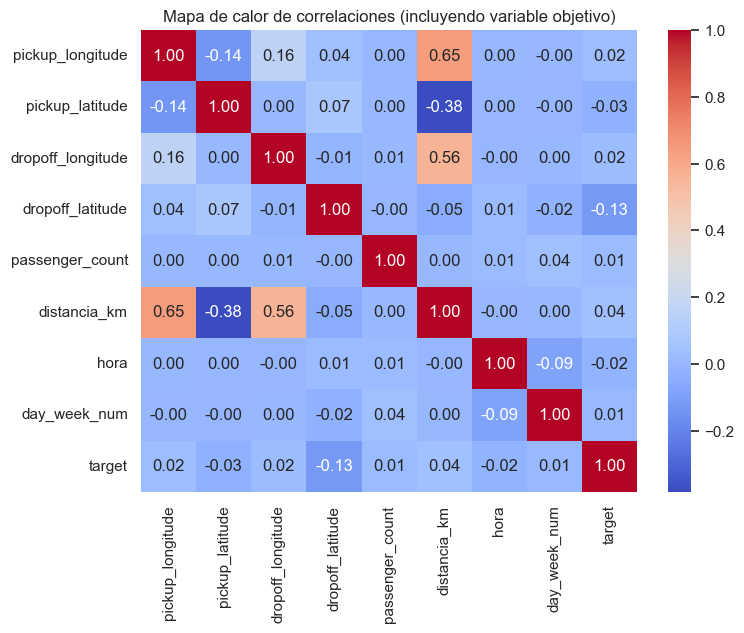

In [139]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train[['pickup_longitude', 'pickup_latitude', 
                         'dropoff_longitude', 'dropoff_latitude', 
                         'passenger_count', 'distancia_km', 'hora', 
                         'day_week_num']].copy()
data_combined['target'] = y_train

corr = data_combined.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

In [140]:
X_train

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_escalada,pickup_latitude_escalada,...,passenger_count_desescalada,distancia_km,day_week_num,day_week_num_sin,day_week_num_cos,fecha_hora,hora,period_of_the_day,hora_sin,hora_cos
48971,34596106,2015-01-06 16:30:04.0000002,2015-01-06 16:30:04 UTC,-73.996948,40.737476,-74.005592,40.738586,1,-0.619042,-0.506585,...,1.0,0.738675,1,0.781831,0.623490,2015-01-06 16:30:04.000000200+00:00,16,Tarde,-0.866025,-0.500000
131208,2147393,2012-01-07 15:22:25.0000001,2012-01-07 15:22:25 UTC,-73.993049,40.759392,-73.990639,40.751125,1,-0.456445,0.196053,...,1.0,0.941397,5,-0.974928,-0.222521,2012-01-07 15:22:25.000000100+00:00,15,Tarde,-0.707107,-0.707107
15045,50775201,2010-04-16 15:17:00.000000204,2010-04-16 15:17:00 UTC,-73.989005,40.758418,-73.870420,40.773570,2,-0.287811,0.164826,...,2.0,10.128021,4,-0.433884,-0.900969,2010-04-16 15:17:00.000000204+00:00,15,Tarde,-0.707107,-0.707107
11426,17264957,2009-12-31 23:39:28.0000009,2009-12-31 23:39:28 UTC,-73.991654,40.733589,-73.985400,40.745320,4,-0.398274,-0.631218,...,4.0,1.406828,3,0.433884,-0.900969,2009-12-31 23:39:28.000000900+00:00,23,Noche,-0.258819,0.965926
49247,30842630,2009-07-06 20:52:00.00000023,2009-07-06 20:52:00 UTC,-73.967235,40.788065,-73.985768,40.747167,2,0.619991,1.115340,...,2.0,4.808030,0,0.000000,1.000000,2009-07-06 20:52:00.000000230+00:00,20,Noche,-0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119887,23426202,2014-10-30 08:33:00.000000109,2014-10-30 08:33:00 UTC,-73.885343,40.773065,-73.973907,40.784050,1,4.034861,0.634424,...,1.0,7.556580,3,0.433884,-0.900969,2014-10-30 08:33:00.000000109+00:00,8,Mañana,0.866025,-0.500000
103701,21290919,2013-05-17 10:40:00.000000199,2013-05-17 10:40:00 UTC,-73.992142,40.749410,-74.015142,40.709645,1,-0.418623,-0.123980,...,1.0,4.827759,4,-0.433884,-0.900969,2013-05-17 10:40:00.000000199+00:00,10,Mañana,0.500000,-0.866025
131940,34840847,2009-11-08 14:37:00.000000205,2009-11-08 14:37:00 UTC,-73.992528,40.714083,-73.992703,40.728007,1,-0.434719,-1.256601,...,1.0,1.548351,6,-0.781831,0.623490,2009-11-08 14:37:00.000000205+00:00,14,Tarde,-0.500000,-0.866025
146877,16683017,2009-11-14 03:27:22.0000002,2009-11-14 03:27:22 UTC,-73.985502,40.768050,-73.950450,40.775060,1,-0.141737,0.473638,...,1.0,3.052921,5,-0.974928,-0.222521,2009-11-14 03:27:22.000000200+00:00,3,Madrugada,0.707107,0.707107


In [141]:
columnas_escaladas_especificas = [
    'pickup_longitude_escalada',
    'pickup_latitude_escalada',
    'dropoff_longitude_escalada',  
    'dropoff_latitude_escalada',   
    'day_week_num_sin',
    'day_week_num_cos',
    'hora_sin',
    'hora_cos',
    'passenger_count_escalada',
    'distancia_km'    
]

columnas_existentes = [col for col in columnas_escaladas_especificas if col in X_train.columns]

X_train_scaled = X_train[columnas_existentes].copy()

In [142]:
X_train_scaled.head()

,pickup_longitude_escalada,pickup_latitude_escalada,dropoff_longitude_escalada,dropoff_latitude_escalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count_escalada,distancia_km
48971,-0.619042,-0.506585,-0.952329,-0.457066,0.781831,0.623490,-0.866025,-0.500000,0.0,0.738675
131208,-0.456445,0.196053,-0.383944,-0.078675,-0.974928,-0.222521,-0.707107,-0.707107,0.0,0.941397
15045,-0.287811,0.164826,4.185643,0.598675,-0.433884,-0.900969,-0.707107,-0.707107,1.0,10.128021
11426,-0.398274,-0.631218,-0.184807,-0.253859,0.433884,-0.900969,-0.258819,0.965926,3.0,1.406828
49247,0.619991,1.115340,-0.198795,-0.198120,0.000000,1.000000,-0.866025,0.500000,1.0,4.808030


# Regresion lineal

In [143]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
